# Customer Segmentation Using K-Means

The goal of this project is to segment customers into meaningful groups based on their behavior and demographics using K-Means clustering.
- Understand customer patterns
- Build clusters using K-Means
- Interpret business insights from clusters

Full project overview and business context: see README.md

In [1]:
# Prevents KMeans memory leak on Windows with MKL by disabling multithreading
import os

os.environ['OMP_NUM_THREADS'] = '1'

In [2]:
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.cluster import KMeans

In [3]:
customers = pd.read_csv("data/customers.csv")
customers.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
customers.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [5]:
customers.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


## Data Cleaning and Feature Transformation

In [6]:
# Drop the ID column
customers.drop('ID', axis=1, inplace=True)

# Z_CostContact and Z_Revenue are constant across all customers, meaning they carry no information and cannot differentiate between customers
customers.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True)

### `Year_Birth`

In [7]:
customers['Year_Birth'].sort_values(ascending=True).head()

239     1893
339     1899
192     1900
1950    1940
424     1941
Name: Year_Birth, dtype: int64

Three customers have unrealistic birth years (1893, 1899, 1900), which are likely data entry errors. They are to be removed.

In [8]:
# Remove customers with unrealistic birth years
customers = customers[~customers['Year_Birth'].isin([1893, 1899, 1900])]

`Age` is more intuitive and directly interpretable than `Year_Birth`.

In [9]:
# Add the Age column
customers['Age'] = datetime.now().year - customers['Year_Birth']
# Drop the Year_Birth column
customers.drop('Year_Birth', axis=1, inplace=True)

### `Income`

In [10]:
customers['Income'].sort_values(ascending=False).head()

2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
Name: Income, dtype: float64

One customer has an unrealistic income of 666,666, which is likely a data entry error. This single outlier is to be removed. The customers with incomes ~160K are likely to be high-income customers.

In [11]:
# Remove a customer with unrealistically high inocme
customers = customers[customers['Income'] != 666666]

In [12]:
customers['Income'].isnull().sum()

np.int64(24)

In [13]:
try:
    from pyampute.exploration.mcar_statistical_tests import MCARTest
except ImportError:
    !pip install pyampute

# Check the distribution of missing Income values
mcar_test = MCARTest(method='little')
numeric_cols_for_mcar = customers.select_dtypes(include='number').columns.tolist()
p_value = mcar_test.little_mcar_test(customers[numeric_cols_for_mcar])
print(f"Little's MCAR test p-value: {p_value:.2f}")

Little's MCAR test p-value: 0.17


With only 24 missing values out of 2236 remaining after deleting outliers (1.1%), the choice of imputation strategy has negligible impact on clustering results. Even if all 24 records are assigned to a different cluster, business recommendations would remain unchanged. However, since `Income` seems to be the dominant segmentation factor, ensuring its integrity was a conscious decision rather than an assumption.

Little's MCAR test confirms that missing `Income` values are randomly distributed (p-value = 0.17 > 0.05). Global median imputation is therefore appropriate.

In [14]:
# Filling missing Income values with median for EDA purposes
# SimpleImputer in the pipeline will handle missing values in case new data arrives
customers['Income'] = customers['Income'].fillna(customers['Income'].median())

### `Dt_Customer`

`Dt_Customer` is the customer registration date, which is not useful as-is. It makes sense to transform it to `YearsAsCustomer` – a number of years since client registration.

In [15]:
customers['YearsAsCustomer'] = (pd.Timestamp('2024-01-01') - pd.to_datetime(customers['Dt_Customer'], format='%d-%m-%Y')).dt.days / 365
customers['YearsAsCustomer'] = customers['YearsAsCustomer'].round(1)

customers.drop('Dt_Customer', axis=1, inplace=True)

In [16]:
print(customers['YearsAsCustomer'].describe())

count    2236.000000
mean       10.483497
std         0.555784
min         9.500000
25%        10.000000
50%        10.500000
75%        11.000000
max        11.400000
Name: YearsAsCustomer, dtype: float64


### `Education`

In [17]:
customers['Education'].value_counts()

Education
Graduation    1126
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

`Education` has 5 clean categories, no anomalies or data entry errors detected. The majority of customers are *Graduation* (1127), *PhD* (485) and *Master* (370).

### `Marital_Status`

In [18]:
customers['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    578
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

*Alone*, *Absurd* and *YOLO* are all treated as *Single* – these are either errors or jokes.

For a retail segmentation task, what matters is household structure and buying behavior, not the specific reason why a customer is single.
    
`Income` already captures financial differences, and groups like *Widow* (77) and *Divorced* (232) are too small to form meaningful clusters. So `Marital_Status` is binarized into `HasPartner` (1 = Married/Together, 0 = otherwise).

In [19]:
# Add the HasPartner column
customers['HasPartner'] = customers['Marital_Status'].map(
    lambda x: 1 if x in ['Married', 'Together'] else 0
)
# Drop the Marital_Status column
customers = customers.drop(columns=['Marital_Status'])

In [20]:
customers['HasPartner'].isnull().sum()

np.int64(0)

In [21]:
customers['HasPartner'].value_counts()

HasPartner
1    1442
0     794
Name: count, dtype: int64

## Exploratory Data Analysis

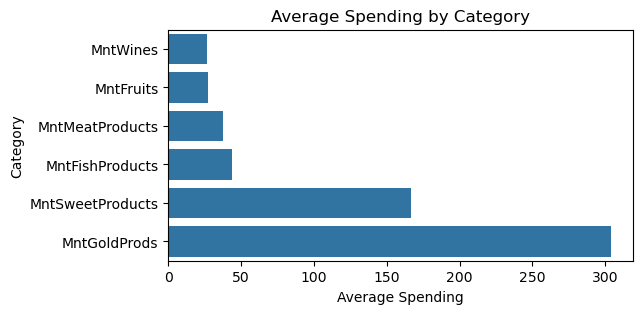

In [22]:
# Average spending by category
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

plt.figure(figsize=(6, 3))
sns.barplot(y=mnt_cols, x=customers[mnt_cols].mean().sort_values())
plt.title('Average Spending by Category')
plt.xlabel('Average Spending')
plt.ylabel('Category')
plt.show()

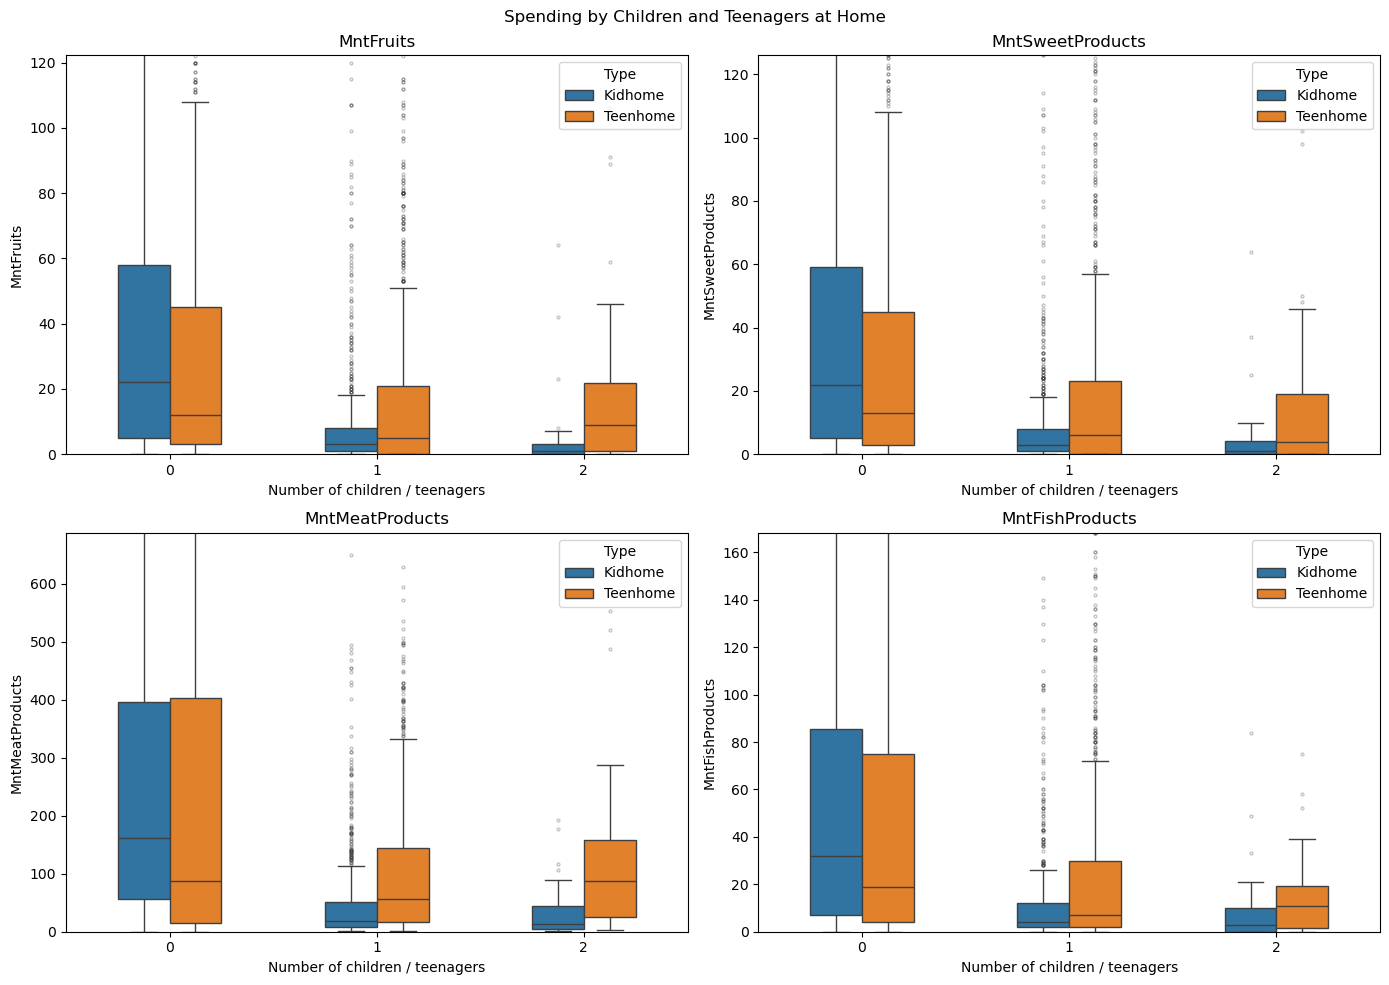

In [23]:
# Explore spendings on fruits, sweets, meat, and fish
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cols = ['MntFruits', 'MntSweetProducts', 'MntMeatProducts', 'MntFishProducts']
# Set 95th percentile as upper limit to cut visual outliers
limits = {col: customers[col].quantile(0.95) for col in cols}

customers_children = customers.melt(
    id_vars=['MntFruits', 'MntSweetProducts', 'MntMeatProducts', 'MntFishProducts'],
    value_vars=['Kidhome', 'Teenhome'],
    var_name='Type',
    value_name='Count'
)

for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(data=customers_children, x='Count', y=col, hue='Type', ax=ax, width=0.5,
                flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
    ax.set_title(col)
    ax.set_xlabel('Number of children / teenagers')
    ax.set_ylim(0, limits[col])
    ax.legend(title='Type')

for ax in axes.flatten():
    ax.legend(title='Type', loc='upper right')
    
plt.suptitle('Spending by Children and Teenagers at Home')
plt.tight_layout()
plt.show()

Customers without children (`Kidhome`=0) show the highest spending across all categories. 

Spending drops sharply with each additional child (`Kidhome`), while the effect of teenagers (`Teenhome`) is less pronounced: households with 1-2 teenagers maintain relatively higher spending, particularly visible in `MntFruits` and `MntSweetProducts`.

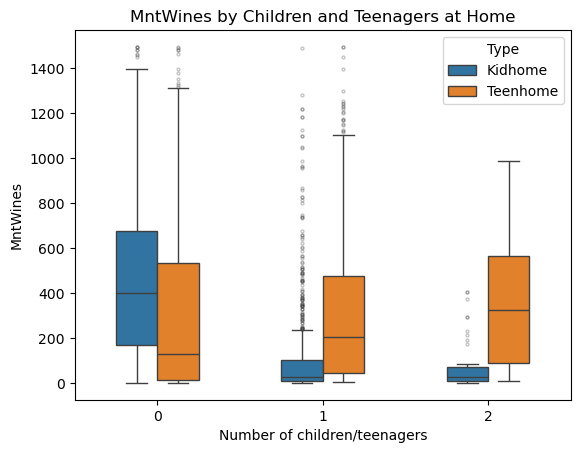

In [24]:
# Explore spendings on wine
customers_wines = customers.melt(
    id_vars=['MntWines'],
    value_vars=['Kidhome', 'Teenhome'],
    var_name='Type',
    value_name='Count'
)

sns.boxplot(data=customers_wines, x='Count', y='MntWines', hue='Type', width=0.5,
            flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
plt.title('MntWines by Children and Teenagers at Home')
plt.xlabel('Number of children/teenagers')
plt.legend(title='Type', loc='upper right')
plt.show()

Wine spending drops with each additional young child (`Kidhome`), with the sharpest drop between `Kidhome`=0 and `Kidhome`=1.

Teenagers (`Teenhome`) show a different pattern: customers with no teenagers spend less on wine than those with no young children, but wine spending actually increases for households with 2 teenagers compared to 1. This likely reflects older, higher-income households where teenagers are more independent and parents have more disposable income. 

Overall, the presence of young children suppresses wine spending more strongly than teenagers do.

In [25]:
numeric_cols_for_heatmap = [
    'Income', 'Age', 'YearsAsCustomer', 'Recency', 'Kidhome', 'Teenhome',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'
]

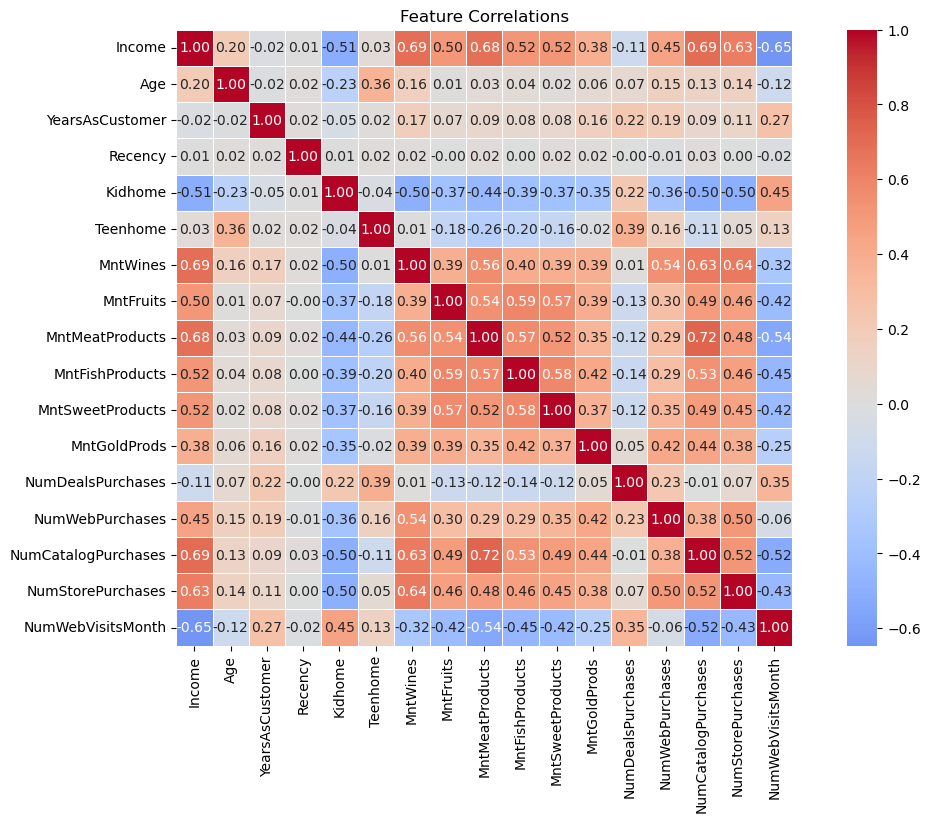

In [26]:
plt.figure(figsize=(14, 8))
sns.heatmap(customers[numeric_cols_for_heatmap].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlations')
plt.show()

In [27]:
corr_matrix = customers[numeric_cols_for_heatmap].corr().abs()

# Get upper triangle only to avoid duplicates
corr_pairs = (corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation'})
    .sort_values('Correlation', ascending=False)
)

corr_pairs['Correlation'] = corr_pairs['Correlation'].round(2)
print(corr_pairs.head(20).to_string(index=False))

          Feature 1           Feature 2  Correlation
    MntMeatProducts NumCatalogPurchases         0.72
             Income NumCatalogPurchases         0.69
             Income            MntWines         0.69
             Income     MntMeatProducts         0.68
             Income   NumWebVisitsMonth         0.65
           MntWines   NumStorePurchases         0.64
           MntWines NumCatalogPurchases         0.63
             Income   NumStorePurchases         0.63
          MntFruits     MntFishProducts         0.59
    MntFishProducts    MntSweetProducts         0.58
    MntMeatProducts     MntFishProducts         0.57
          MntFruits    MntSweetProducts         0.57
           MntWines     MntMeatProducts         0.56
           MntWines     NumWebPurchases         0.54
          MntFruits     MntMeatProducts         0.54
    MntMeatProducts   NumWebVisitsMonth         0.54
    MntFishProducts NumCatalogPurchases         0.53
    MntMeatProducts    MntSweetProducts       

In [28]:
try:
    from pingouin import partial_corr
except ImportError:
    !pip install pingouin
    from pingouin import partial_corr

In [29]:
# Check partial correlation between MntMeatProducts and NumCatalogPurchases
result = partial_corr(customers, x='MntMeatProducts', y='NumCatalogPurchases', covar='Income')
print(f"Regular correlation: 0.72")
print(f"Partial correlation (controlling for Income): {result['r'].values[0]:.2f}")

Regular correlation: 0.72
Partial correlation (controlling for Income): 0.47


Top correlated pairs are all centered around `Income` and spending behavior. 

`MntMeatProducts` and `NumCatalogPurchases` (0.72) is the strongest pair. Partial correlation controlling for `Income` drops to 0.47, confirming that `Income` partially explains this relationship: high-income customers spend more on meat and prefer catalog purchasing independently. However, a genuine association between meat spending and catalog channel preference exists beyond what income alone explains. Without transaction-level data, it is impossible to confirm that meat is purchased directly through catalogs.

Wine spending `MntWines` strongly correlates with store (0.64) and catalog (0.63) purchases, suggesting that wine buyers prefer offline and catalog channels.

`Income` drives spending across all categories and correlates strongly with catalog and store purchases(`NumCatalogPurchases` and `NumStorePurchases`, respectively), but negatively with `NumWebVisitsMonth` (-0.65), confirming that low-income customers tend to window-shop online rather than convert to actual buyers.

`Recency` shows near-zero correlation with everything. This feature is unlikely to contribute to cluster separation.

`Kidhome` consistently appears in the mid-range, negatively pulling down spending across all categories.

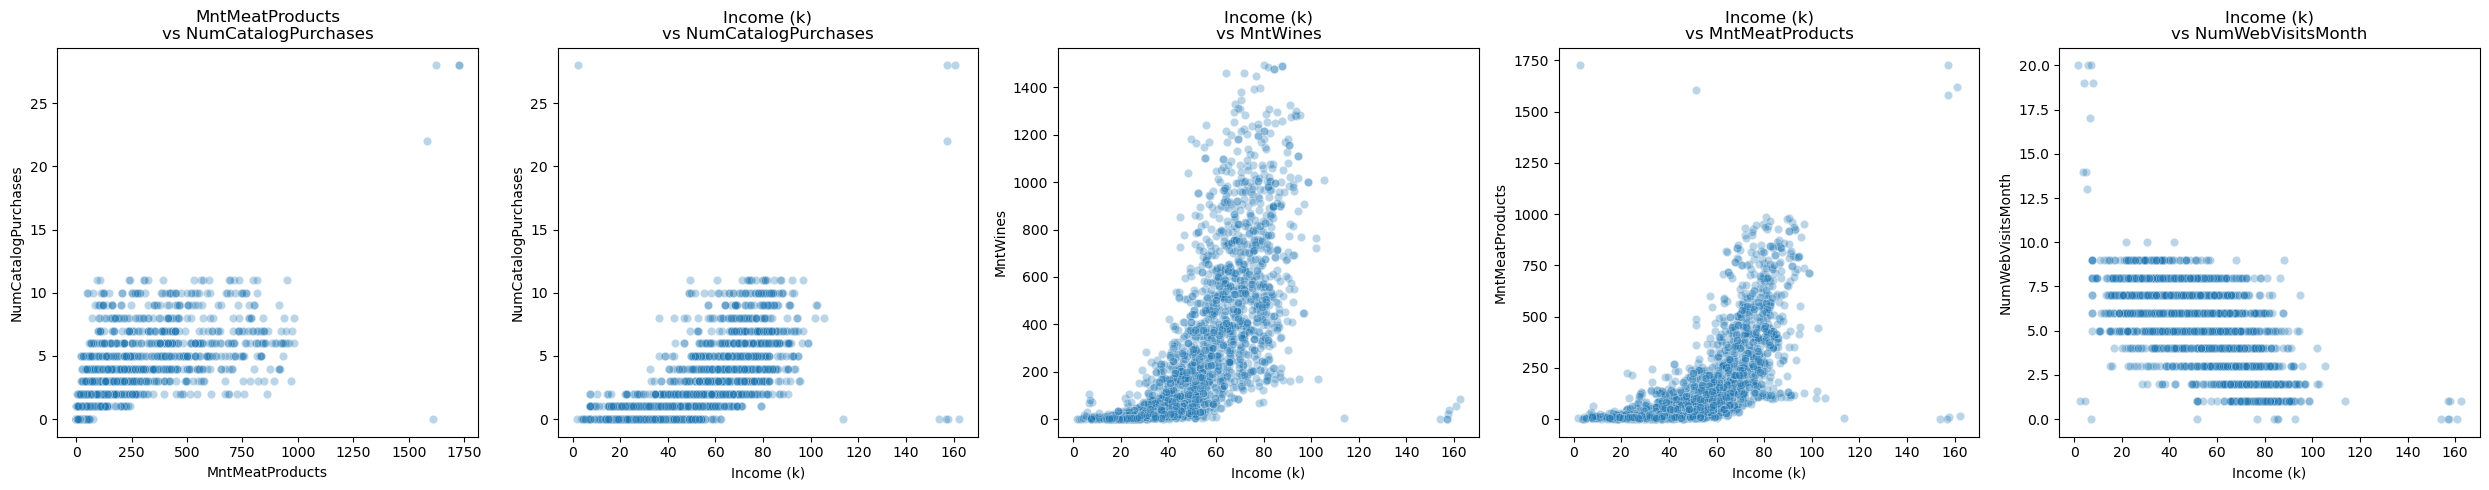

In [30]:
customers['Income_k'] = customers['Income'] / 1000

# Analyze top correlated pairs
top_pairs_k = [
    ('MntMeatProducts', 'NumCatalogPurchases'),
    ('Income_k', 'NumCatalogPurchases'),
    ('Income_k', 'MntWines'),
    ('Income_k', 'MntMeatProducts'),
    ('Income_k', 'NumWebVisitsMonth'),
]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (x, y) in zip(axes, top_pairs_k):
    sns.scatterplot(customers, x=x, y=y, alpha=0.3, ax=ax)
    xlabel = x.replace('_k', ' (k)') if '_k' in x else x
    ax.set_xlabel(xlabel)
    ax.set_title(f"{xlabel}\nvs {y}")

plt.tight_layout()
plt.show()

# Drop temporary column
customers = customers.drop(columns=['Income_k'])

#### Data Insights from Top Correlated Pairs Analysis

1. Higher income customers spend more on meat products, which is an expected pattern as meat is a higher-cost category.
2. Higher income customers purchase more frequently through catalogs, suggesting catalogs are a premium channel.
3. Wine spending shows high variance among mid-income customers (40-80k): some spend almost nothing, others spend heavily. At this income level, spending is likely driven by personal habits rather than budget constraints.
4. High-income customers visit the website less frequently, suggesting they prefer offline or catalog purchasing over online browsing.

The remaining pairs in the correlation list represent variations of the same patterns already observed in the top 5: incme-driving spending and channel preference, and intercorrelations within the `Mnt*` block. No new behavioral patterns are expected.

### Data Insights Drawn from EDA

* `Income` is the central driver of customer behavior, strongly linked to spending across all categories and purchase channels, especially `NumCatalogPurchases` (0.69) and `NumStorePurchases` (0.63).
* Among mid-income customers (40-80k), wine spending `MntWines` shows high variance: some spend almost nothing, others spend heavily. At this income level, behavior is likely driven by personal habits rather than budget constraints.
* High-income customers rarely visit the website (r=-0.65 for `NumWebVisitsMonth`), preferring catalog and store purchasing over online browsing.
* `NumCatalogPurchases` seems to be a premium channel: it is strongly linked to both `Income` (0.69) and `MntMeatProducts` (0.72).
* `Kidhome` consistently suppresses spending across all categories, with the strongest effect on `MntWines` (-0.50) and `MntMeatProducts` (-0.44).
* `Teenhome` shows a weaker and less consistent pattern.
* All `Mnt*` features are moderately intercorrelated (0.39-0.59), suggesting they represent different aspects of the same spending dimension.
* `Recency` shows near-zero correlation with all features (max 0.02), suggesting it carries little signal for cluster separation.
* `Age` shows weak direct correlation with spending features. Its modest correlation with other variables is largely mediated by `Kidhome` and `Teenhome`: older customers tend to have teenage rather than young children, which indirectly affects spending patterns. `Age` therefore contributes little independent information for cluster separation.

## Data Preprocessing

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [32]:
categorical_features = ['Education']

binary_features = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'Response', 'HasPartner']

numeric_features = [f for f in customers.columns if f not in categorical_features + binary_features]

In [33]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),

    ('cat', OneHotEncoder(drop='first', sparse_output=False),
     categorical_features),

    ('bin', 'passthrough', binary_features),
])

X_scaled = preprocessor.fit_transform(customers)

## Determining the Optimal Number of Clusters

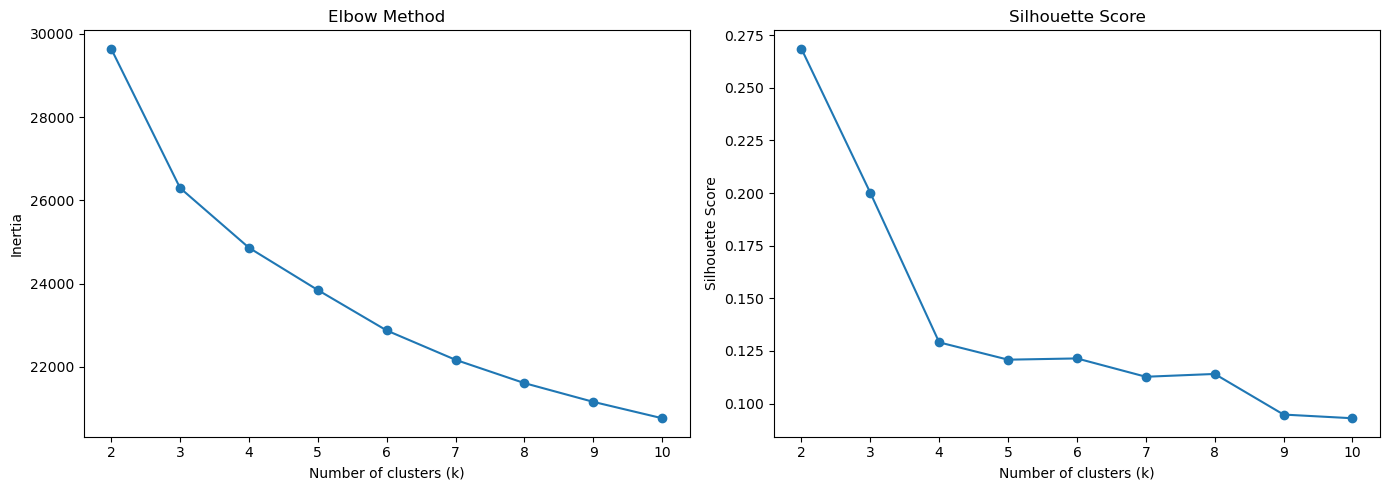

In [34]:
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, inertias,'-o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_range)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, '-o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

Despite having the highest silhouette score (~0.27), k=2 is dismissed since it offers no more insight than a simple income-based threshold, requiring no clustering algorithm at all.

> The elbow curve and silhouette score (0.20) both support `k=3` as the optimal number of clusters, balancing cluster quality and business interpretability.

## Modeling: Three Clusters

In [35]:
# Train a KMeans model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customers['Cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster sizes
cluster_sizes = pd.DataFrame({
    'count': customers['Cluster'].value_counts().sort_index(),
    'proportion': customers['Cluster'].value_counts(normalize=True).sort_index().round(2)
})

print(cluster_sizes)

         count  proportion
Cluster                   
0         1020        0.46
1          624        0.28
2          592        0.26


## Results and Interpretation
### Cluster Profiles

In [36]:
cluster_profiles = customers.groupby('Cluster')[numeric_features].mean().round(1)
print(cluster_profiles.T)

Cluster                    0        1        2
Income               34774.2  57607.0  75590.1
Kidhome                  0.8      0.2      0.0
Teenhome                 0.4      0.9      0.2
Recency                 49.5     48.4     49.2
MntWines                40.2    462.9    591.5
MntFruits                4.9     20.3     69.4
MntMeatProducts         22.8    132.7    451.5
MntFishProducts          7.0     28.4     99.8
MntSweetProducts         5.0     21.7     70.8
MntGoldProds            15.1     60.0     76.8
NumDealsPurchases        2.0      3.8      1.3
NumWebPurchases          2.1      6.3      5.2
NumCatalogPurchases      0.5      3.0      5.9
NumStorePurchases        3.2      7.6      8.4
NumWebVisitsMonth        6.5      5.8      2.8
Age                     54.0     61.7     57.6
YearsAsCustomer         10.4     10.6     10.5


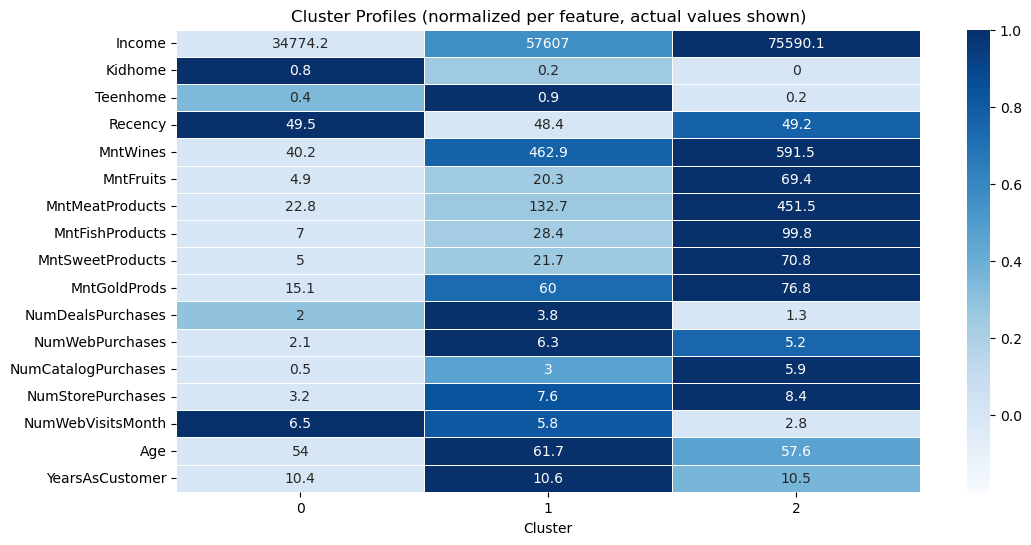

In [37]:
cluster_profiles = customers.groupby('Cluster')[numeric_features].mean()

# Normalize each feature independently across clusters to make colors comparable regardless of scale differences
cluster_profiles_norm = cluster_profiles.apply(
    lambda x: (x - x.min()) / (x.max() - x.min()), axis=0
)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles_norm.T,
            annot=cluster_profiles.T.round(1),
            fmt='g',
            cmap='Blues',
            linewidths=0.5,
            vmin=-0.2,
            cbar_kws={'ticks': [0, 0.2, 0.4, 0.6, 0.8, 1.0]})
plt.title('Cluster Profiles (normalized per feature, actual values shown)')
plt.show()

> Note: color contrast reflects relative differences within each feature. Features with small absolute variation (e.g. `Recency`: 48-50) appear visually prominent despite negligible practical differences.

The three clusters show little variation in `Age`, `Recency`, and `YearsAsCustomer`, confirming these features contribute minimally to cluster separation.

* **Budget Families (\~46%)**
    - Lowest income (\~35k)
    - Highest `Kidhome` (0.8)
    - Spending is minimal across all categories
    - Despite rarely purchasing online or through catalogs, this group visits the website most frequently – they tend to window-shop online rather than convert to actual buyers

* **Deal Seekers (\~28%)**
    - Middle income (\~58k)
    - Highest `Teenhome` (0.9)
    - Spending is moderate, with a notably smaller gap vs Premium Buyers in wines and gold products
    - Most deal-oriented group (`NumDealsPurchases`=3.8)
    - Most active online, highest `NumWebPurchases`
    - `NumStorePurchases` nearly match Premium Buyers, but `NumCatalogPurchases` are significantly lower.
    - Deal Seekers spend nearly as much on wine as **Premium Buyers** (462.9 vs 591.5) despite having significantly lower income (\~57k vs \~76k), suggesting that wine is a priority purchase for this segment regardless of budget constraints.

* **Premium Buyers (\~26%)**
    - Highest income (\~76k)
    - No young children (`Kidhome`=0), rarely teenagers (`Teenhome`=0.2)
    - Maximum spending across all categories
    - Least interested in deals
    - Premium Buyers are the heaviest wine spenders (591.5 on average)
    - Despite low website visit frequency (`NumWebVisitsMonth`=2.8, lowest across all clusters), they purchase online fairly often and use catalogs more than any other group

In [38]:
# Map clusters to meaningful names based on Income level
cluster_income = customers.groupby('Cluster')['Income'].mean().sort_values()

# Assign labels: lowest income = 0, middle = 1, highest = 2
cluster_mapping = {cluster_income.index[0]: 0,  # Budget Families
                   cluster_income.index[1]: 1,  # Deal Seekers  
                   cluster_income.index[2]: 2}  # Premium Buyers

customers['Cluster'] = customers['Cluster'].map(cluster_mapping)

### Cluster Composition Analysis
Distribution of categorical and discrete features across clusters complements the heatmap by examining non-continuous variables.

In [39]:
cluster_names = {0: 'Budget Families', 1: 'Deal Seekers', 2: 'Premium Buyers'}

pd.crosstab(customers['Cluster'].map(cluster_names), 
            customers['Education'], 
            normalize='index').round(2)

Education,2n Cycle,Basic,Graduation,Master,PhD
Cluster,,,,,
Budget Families,0.11,0.05,0.49,0.16,0.19
Deal Seekers,0.06,0.00,0.48,0.19,0.27
Premium Buyers,0.09,0.00,0.56,0.14,0.20


In [40]:
pd.crosstab(customers['Cluster'].map(cluster_names), 
            customers['HasPartner'], 
            normalize='index').round(2)

HasPartner,0,1
Cluster,,
Budget Families,0.36,0.64
Deal Seekers,0.32,0.68
Premium Buyers,0.38,0.62


In [41]:
pd.crosstab(customers['Cluster'].map(cluster_names), 
            customers['Kidhome'], 
            normalize='index').round(2)

Kidhome,0,1,2
Cluster,,,
Budget Families,0.24,0.72,0.04
Deal Seekers,0.78,0.21,0.01
Premium Buyers,0.95,0.05,0.00


In [42]:
pd.crosstab(customers['Cluster'].map(cluster_names), 
            customers['Teenhome'], 
            normalize='index').round(2)

Teenhome,0,1,2
Cluster,,,
Budget Families,0.58,0.41,0.01
Deal Seekers,0.12,0.82,0.06
Premium Buyers,0.83,0.17,0.00


In [43]:
customers.groupby(customers['Cluster'].map(cluster_names))[['Income', 'Kidhome', 'Teenhome']].mean().round(2)


,Income,Kidhome,Teenhome
Cluster,,,
Budget Families,34774.20,0.80,0.43
Deal Seekers,57607.03,0.23,0.94
Premium Buyers,75590.07,0.05,0.17


In [44]:
customers[customers['Cluster'] == 0]['Teenhome'].value_counts()

Teenhome
0    590
1    417
2     13
Name: count, dtype: int64

`Kidhome` and `Teenhome` show the most distinct distributions across clusters, confirming household structure as a key differentiating factor:
- **Premium Buyers** are almost exclusively child-free (95% no young children, 83% no teenagers)
- **Deal Seekers** are predominantly households with one teenager (82%), with very few young children (78% `Kidhome`=0)
- **Budget Families** are largely households with one young child (72%), with a more mixed teenager pattern (58% no teenagers, 41% with one)

`Education` and `HasPartner` are uniformly distributed across all clusters, confirming they are not meaningful segmentation drivers. Behavioral and income differences define the segments, not demographics.

### PCA Visualization

PCA is used for visualization only. K-Means was trained on all 29 features.

In [45]:
from sklearn.decomposition import PCA

# Reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total: {sum(pca.explained_variance_ratio_):.1%}")

Explained variance: PC1=34.4%, PC2=11.2%
Total: 45.6%


PC1 and PC2 explain 34.4% and 11.2% of variance respectively. PCA retains only 45.6% of variance in 2D, reflecting the nature of this dataset: while `Income` dominates as the primary factor, the remaining variance is distributed across many weakly correlated features rather than concentrated in a few clear dimensions. Сluster overlap in this 2D projection does not necessarily reflect poor separation in the full feature space.

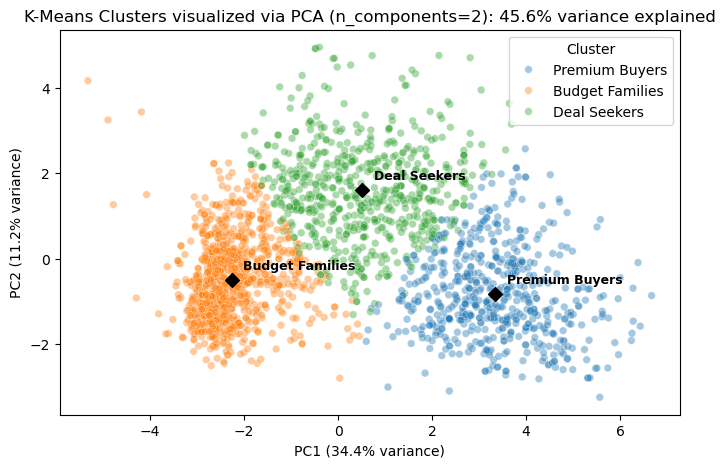

In [46]:
# Transform cluster centers to PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=customers['Cluster'].map(cluster_names),
                alpha=0.4, s=30)

# Plot centroids
for i, (x, y) in enumerate(centroids_pca):
    plt.scatter(x, y, c='black', s=50, marker='D', zorder=5)
    plt.annotate(cluster_names[i], (x, y), 
                textcoords='offset points', xytext=(8, 8),
                fontsize=9, fontweight='bold')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'K-Means Clusters visualized via PCA (n_components=2): {sum(pca.explained_variance_ratio_):.1%} variance explained')
plt.legend(title='Cluster')
plt.show()

Visible overlap between clusters in this 2D projection is expected: 54.4% of variance is lost in dimensionality reduction. Cluster boundaries in the full 29-dimensional space may be
considerably sharper than they appear here.

### PCA Visualization Insights

* `PC1` is the primary separating axis, reflecting income and spending levels: **Budget Families** on the left, **Premium Buyers** on the right, **Deal Seekers** in between.
* **Budget Families** form a relatively compact cluster with a few distant outliers, while **Deal Seekers** and **Premium Buyers** show similar density and spread.
* All three centroids are well-centered within their respective clouds, confirming stable cluster assignment.
* **Deal Seekers** overlap more with both neighboring clusters than those overlap with each other, which is consistent with their intermediate income level and greater internal heterogeneity: this segment contains the most mixed
household structures (`Kidhome` and `Teenhome` distributions are less extreme than in the other two clusters), making it inherently less cohesive.

## Business Recommendations

### Budget Families (\~46%)
**Profile:** 
- Lowest income (\~35k)
- Young children
- Minimal spending
- High web visit frequency suggests price-sensitivity — they browse a lot, but prefer window shopping

**Tactics:**
- Email campaigns with discount coupons and weekly deals
- Online promotions
- Focus on everyday essentials rather than premium categories

### Deal Seekers (\~28%)
**Profile:** 
- Middle income (\~57k)
- Predominantly one teenager at home
- Most deal-oriented segment
- Wine spending nearly matches Premium Buyers despite lower income — wine is clearly a priority purchase for this segment

**Tactics:**
- Promote wine deals across all channels — both online and in-store, as this segment is active on both
- Volume discounts on wine (e.g. buy 5 get 1 free) — high likelihood of response given strong wine preference and deal-seeking behavior
- Discounts on premium wines specifically — for this segment wine is a treat, not a necessity, so aspirational offers are likely to resonate with this segment
- Regular deal newsletters and in-store promotions to maintain engagement

### Premium Buyers (\~26%)
**Profile:** 
- Highest income (\~76k)
- No young children
- Maximum spending across all categories
- Prefer store and catalog channels, rarely visit the website
- Not interested in deals

**Tactics:**
- Early access to limited wine collections and new arrivals
- Personalized catalogs with wine critic recommendations
- In-store wine tastings and degustation events
- Targeted wine campaign to identify wine enthusiasts within the segment —  not all Premium Buyers spend equally on wine, so measuring response
  to a wine-specific offer would reveal the most engaged sub-group
- Premium meat and seafood selections — this segment also leads in meat and fish spending

## Dataset Limitations

1. **Lack of transactional-level data**

The dataset captures total spending per category, not purchase frequency or individual transaction details. For example, it is impossible to distinguish between a customer who buys wine frequently at a low price point and one who occasionally purchases expensive bottles — both show identical total spending. Similarly, channel preferences are known at the aggregate level only, and there is no way of knowing which specific products are purchased through each channel.

2. **`Income` as a dominant factor**

Most spending features correlate strongly with `Income`, making it difficult to identify preference-driven patterns independent of purchasing power. Knowing what share of their budget customers spend on each category (rather than absolute amounts) would reveal genuine product preferences
regardless of income level.

3. **Ambiguous features**

`MntGoldProds` does not fit naturally alongside food categories: gold is an occasional purchase for some customers and irrelevant for others, making it difficult to interpret alongside weekly grocery spending patterns.

> Overall, as a result of these limitations, the dataset reveals *how* customers buy (channels, deal-seeking behavior) more clearly than *why* they buy specific products. `MntWines` is a partial exception, showing behavioral variance independent of income, but even here frequency and price point cannot be distinguished.